1️⃣PROBLEM & DATASET

### Problem
Prediksi apakah penumpang Titanic selamat atau tidak berdasarkan fitur seperti umur, jenis kelamin, kelas tiket, dll.

### Tujuan
Membuat model ML yang mampu memprediksi survival penumpang Titanic dengan akurasi optimal.

### Dataset
Dataset Titanic bawaan seaborn memiliki kolom:

- `survived`: target (0 = Tidak selamat, 1 = Selamat)
- `pclass`: Kelas tiket
- `sex`: Jenis kelamin
- `age`: Umur
- `sibsp`: Jumlah saudara/istri
- `parch`: Jumlah orang tua/anak
- `fare`: Harga tiket
- `embarked`: Pelabuhan naik
- `class`, `who`, `adult_male`, `deck`, `embark_town`, `alive`, `alone`

Ukuran dataset: 891 baris x 15 kolom.

In [14]:
# ============================================================
# 1: PROBLEM & DATASET
# ============================================================
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
print("=" * 60)
print("1. PROBLEM & DATASET")
print("=" * 60)
print("Masalah : Prediksi apakah penumpang Titanic selamat atau tidak berdasarkan fitur seperti umur, jenis kelamin, kelas tiket, dll.")
print("Tujuan : Membuat model ML yang mampu memprediksi survival penumpang Titanic dengan akurasi optimal.")
print("Sumber : Dataset Titanic bawaan seaborn ")

# Muat dataset Titanic seaborn
df = sns.load_dataset("titanic")

# Tampilkan info dasar
print(df.shape)
print(df.columns)
print(df.head())

# Pisahkan fitur dan target
X = df.drop(columns=["survived"])
y = df["survived"]

# Split train-test 80-20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

1. PROBLEM & DATASET
Masalah : Prediksi apakah penumpang Titanic selamat atau tidak berdasarkan fitur seperti umur, jenis kelamin, kelas tiket, dll.
Tujuan : Membuat model ML yang mampu memprediksi survival penumpang Titanic dengan akurasi optimal.
Sumber : Dataset Titanic bawaan seaborn 
(891, 15)
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  


## 2 Exploratory Data Analysis (EDA)

Langkah EDA:
1. Cek missing value
2. Statistik deskriptif
3. Minimal 5 visualisasi
4. Menuliskan insight dari data


2. EDA
=== Missing Value per Kolom ===
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


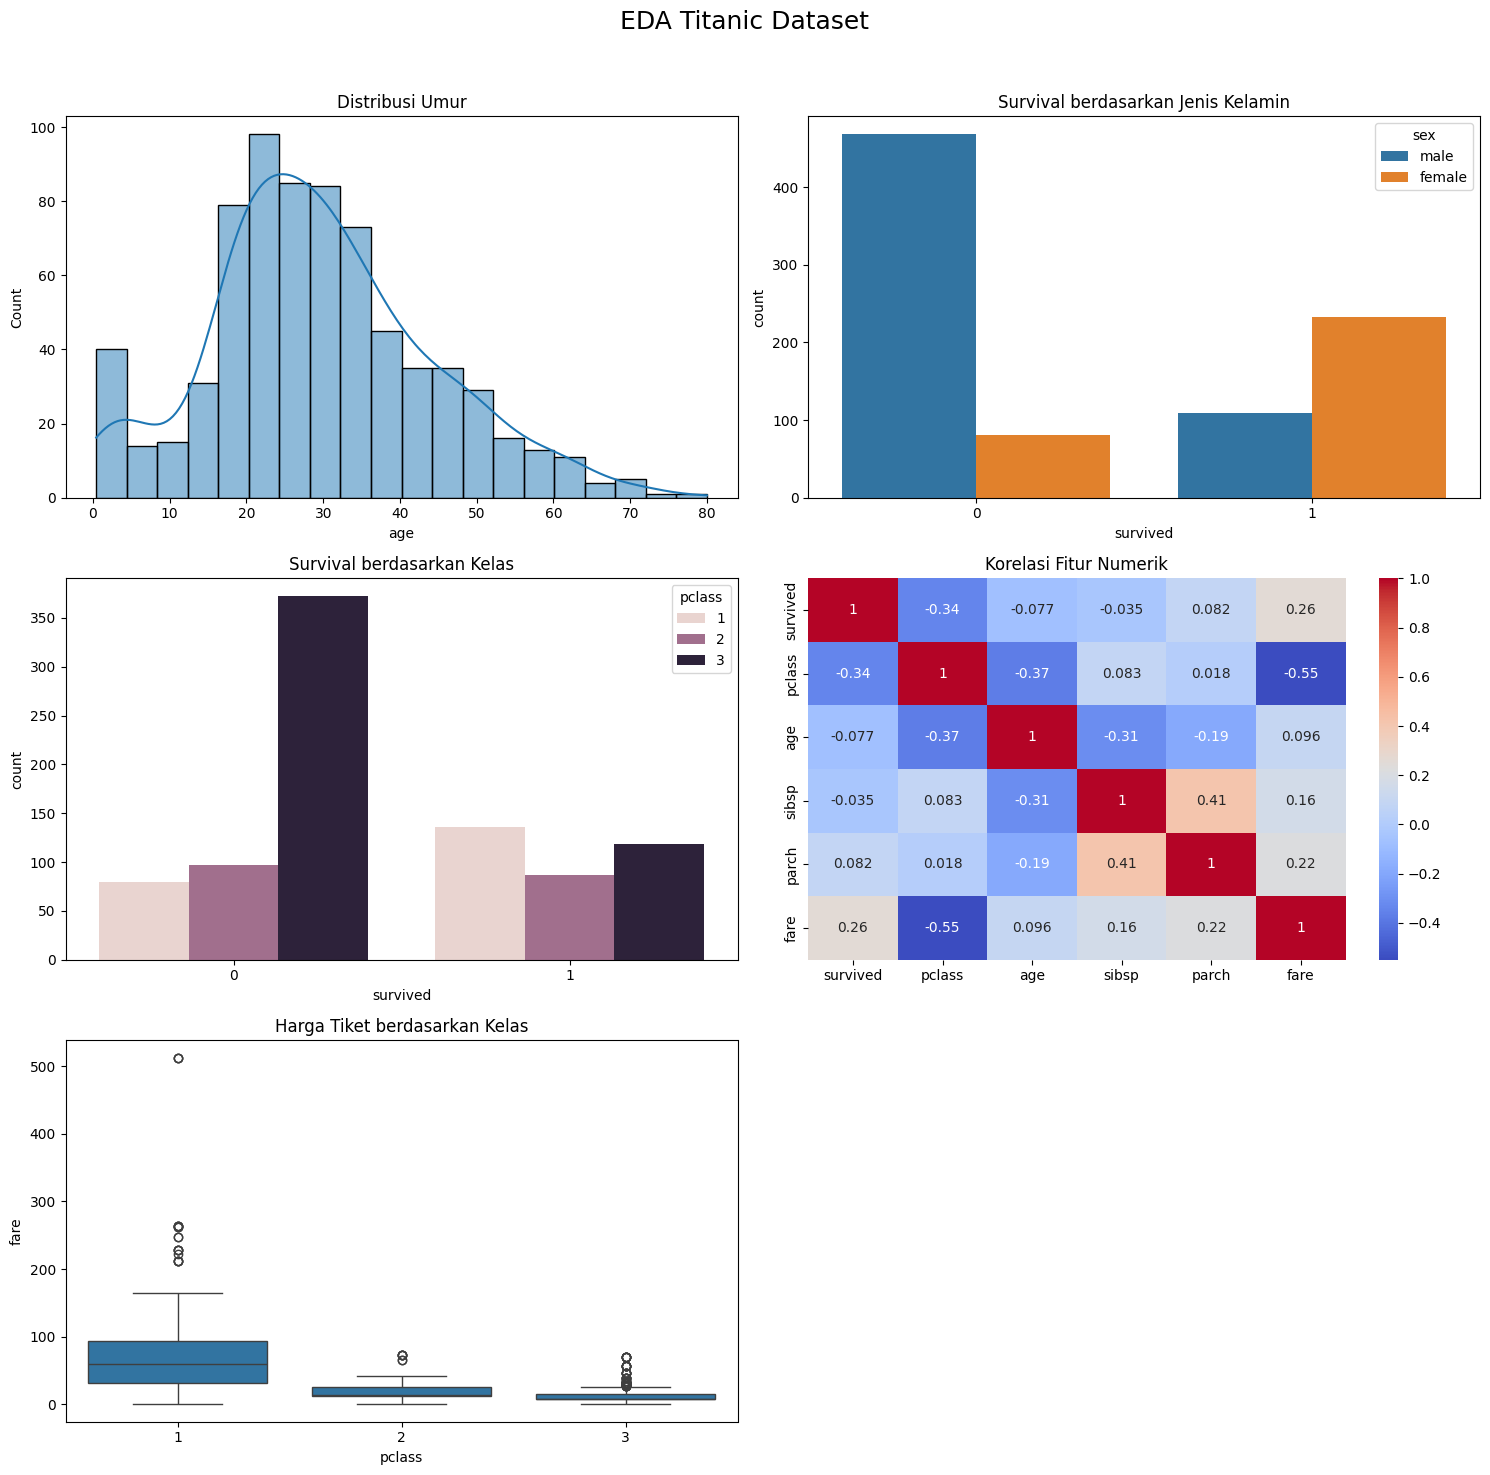


=== Insight ===
1. Survival rate perempuan: 0.74, laki-laki: 0.19
2. Survival rate kelas 1: 0.63
2. Survival rate kelas 2: 0.47
2. Survival rate kelas 3: 0.24
3. Rata-rata umur yang selamat: 28.3, yang meninggal: 30.6
4. Rata-rata harga tiket penumpang selamat: 48.40, yang meninggal: 22.12
5. Kolom dengan missing value terbanyak:
deck           688
age            177
embarked         2
embark_town      2
dtype: int64


In [2]:

# ==========================================================
# 2. EDA
# ==========================================================
print("\n" + "=" * 60)
print("2. EDA")
print("=" * 60)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Muat dataset
df = sns.load_dataset("titanic")

# Cek Missing Value
missing = df.isnull().sum()
print("=== Missing Value per Kolom ===")
print(missing)

# 5 Visualisasi
numeric_cols = df.select_dtypes(include='number')

fig, axes = plt.subplots(3, 2, figsize=(15,15))
fig.suptitle("EDA Titanic Dataset", fontsize=18)

# Distribusi umur
sns.histplot(df['age'], kde=True, ax=axes[0,0])
axes[0,0].set_title("Distribusi Umur")

# Survival berdasarkan jenis kelamin
sns.countplot(x='survived', hue='sex', data=df, ax=axes[0,1])
axes[0,1].set_title("Survival berdasarkan Jenis Kelamin")

# Survival berdasarkan kelas tiket
sns.countplot(x='survived', hue='pclass', data=df, ax=axes[1,0])
axes[1,0].set_title("Survival berdasarkan Kelas")

# Korelasi numerik
sns.heatmap(numeric_cols.corr(), annot=True, ax=axes[1,1], cmap="coolwarm")
axes[1,1].set_title("Korelasi Fitur Numerik")

# Boxplot harga tiket vs kelas
sns.boxplot(x='pclass', y='fare', data=df, ax=axes[2,0])
axes[2,0].set_title("Harga Tiket berdasarkan Kelas")

# Hapus subplot kosong
fig.delaxes(axes[2,1])
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

# Insight
print("\n=== Insight ===")

# Insight 1: Gender survival
female_surv = df[df['sex']=='female']['survived'].mean()
male_surv = df[df['sex']=='male']['survived'].mean()
print(f"1. Survival rate perempuan: {female_surv:.2f}, laki-laki: {male_surv:.2f}")

# Insight 2: Kelas survival
class_surv = df.groupby('pclass')['survived'].mean()
for c in class_surv.index:
    print(f"2. Survival rate kelas {c}: {class_surv[c]:.2f}")

# Insight 3: Umur
avg_age_survived = df[df['survived']==1]['age'].mean()
avg_age_dead = df[df['survived']==0]['age'].mean()
print(f"3. Rata-rata umur yang selamat: {avg_age_survived:.1f}, yang meninggal: {avg_age_dead:.1f}")

# Insight 4: Fare vs survival
avg_fare_survived = df[df['survived']==1]['fare'].mean()
avg_fare_dead = df[df['survived']==0]['fare'].mean()
print(f"4. Rata-rata harga tiket penumpang selamat: {avg_fare_survived:.2f}, yang meninggal: {avg_fare_dead:.2f}")

# Insight 5: Kolom banyak missing
high_missing = missing[missing>0].sort_values(ascending=False)
print("5. Kolom dengan missing value terbanyak:")
print(high_missing)

### Preprocessing Steps
- Drop kolom redundant/missing banyak: `deck`, `embark_town`, `alive`, `class`, `who`, `adult_male`, `alone`
- Isi missing `age` dengan median
- Isi missing `embarked` dengan mode
- Encoding `sex` dan `embarked`
- Scaling numeric features

In [3]:
# ==========================================================
# 3) Preprocessing (Missing Value, Encoding, Scaling, Split)
# ==========================================================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import seaborn as sns

# -----------------------------
# 0) Muat dataset dan pisahkan target
# -----------------------------
df = sns.load_dataset("titanic")
X = df.drop(columns=["survived"])  # fitur
y = df["survived"]                 # target

# Split data: 80% latih, 20% uji
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Split data: 80% train, 20% test\n")

# -----------------------------
# 1) Drop kolom redundant / banyak missing
# -----------------------------
drop_cols = ['deck','embark_town','alive','class','who','adult_male','alone']
X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

print("Alasan Drop Kolom:")
print("- Kolom 'deck' dan 'embark_town' banyak missing (tidak praktis diimputasi)")
print("- Kolom 'alive','class','who','adult_male','alone' bersifat redundant\n")

# -----------------------------
# 2) Handle Missing Value
# -----------------------------
# Age (numerik) → isi dengan median
X_train['age'] = X_train['age'].fillna(X_train['age'].median())
X_test['age'] = X_test['age'].fillna(X_test['age'].median())
print("Alasan Missing Value 'age': diisi median agar robust terhadap outlier")

# Embarked (kategorikal) → isi dengan mode
X_train['embarked'] = X_train['embarked'].fillna(X_train['embarked'].mode()[0])
X_test['embarked'] = X_test['embarked'].fillna(X_test['embarked'].mode()[0])
print("Alasan Missing Value 'embarked': diisi mode agar kategori tetap konsisten\n")

# -----------------------------
# 3) Encoding Kategorikal
# -----------------------------
# Kolom 'sex' dan 'embarked'
le = LabelEncoder()
for col in ['sex','embarked']:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

print("Alasan Encoding:")
print("- Model ML membutuhkan input numerik")
print("- LabelEncoder cukup karena kategori tidak ordinal\n")

# -----------------------------
# 4) Scaling Numerik
# -----------------------------
num_cols = ['age','sibsp','parch','fare']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Alasan Scaling:")
print("- Model seperti KNN dan Logistic Regression sensitif terhadap skala fitur")
print("- StandardScaler → mean=0, std=1 agar semua fitur sebanding\n")

# -----------------------------
# 5) Cek hasil preprocessing
# -----------------------------
print("Shape X_train:", X_train.shape)
print("Shape X_test :", X_test.shape)
print("\nContoh beberapa baris X_train setelah preprocessing:")
print(X_train.head())

Split data: 80% train, 20% test

Alasan Drop Kolom:
- Kolom 'deck' dan 'embark_town' banyak missing (tidak praktis diimputasi)
- Kolom 'alive','class','who','adult_male','alone' bersifat redundant

Alasan Missing Value 'age': diisi median agar robust terhadap outlier
Alasan Missing Value 'embarked': diisi mode agar kategori tetap konsisten

Alasan Encoding:
- Model ML membutuhkan input numerik
- LabelEncoder cukup karena kategori tidak ordinal

Alasan Scaling:
- Model seperti KNN dan Logistic Regression sensitif terhadap skala fitur
- StandardScaler → mean=0, std=1 agar semua fitur sebanding

Shape X_train: (712, 7)
Shape X_test : (179, 7)

Contoh beberapa baris X_train setelah preprocessing:
     pclass  sex       age     sibsp     parch      fare  embarked
331       1    1  1.253641 -0.470722 -0.479342 -0.078684         2
733       2    1 -0.477284 -0.470722 -0.479342 -0.377145         2
382       3    1  0.215086 -0.470722 -0.479342 -0.474867         2
704       3    1 -0.246494  0.

## 4 Modeling

Menggunakan minimal 3 model:
1. Logistic Regression
2. Decision Tree
3. Random Forest

Evaluasi menggunakan Accuracy.

In [ ]:
# ==========================================================
# 4) Modeling Classification
# ==========================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# 3 model classification
models_clf = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results_clf = []

# Latih semua model dan hitung akurasi
for name, model in models_clf.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results_clf.append({"Model": name, "Accuracy": acc})

# Tabel perbandingan
results_clf_df = pd.DataFrame(results_clf).sort_values(by="Accuracy", ascending=False)
print("Tabel Perbandingan:")
print(results_clf_df)

# Pilih model terbaik
best_model_name = results_clf_df.iloc[0]['Model']
best_model = models_clf[best_model_name]
y_pred_best = best_model.predict(X_test)

print(f"\nDetail model terbaik ({best_model_name}):")
print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Tabel Perbandingan:
                 Model  Accuracy
0  Logistic Regression  0.810056
2        Random Forest  0.810056
1        Decision Tree  0.731844

Detail model terbaik (Logistic Regression):
[[90 15]
 [19 55]]
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



## 5 Hyperparameter Tuning

Melakukan tuning pada model terbaik menggunakan GridSearchCV.

In [10]:
# ==========================================================
# 5) TUNING
# ==========================================================

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print("\n=== TUNING RANDOM FOREST ===\n")

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

y_pred_tuned = grid.predict(X_test)
print("Akurasi setelah tuning:", accuracy_score(y_test, y_pred_tuned))


=== TUNING RANDOM FOREST ===

Best Params: {'max_depth': 5, 'n_estimators': 50}
Akurasi setelah tuning: 0.8100558659217877


In [13]:
# ==========================================================
# 6) Kesimpulan
# ==========================================================
print("\n=== KESIMPULAN ===")
print("- Model terbaik: Random Forest sebelum (accuracy sebelum tuning 0.81")
print("- Model terbaik setelah tuning: Random Forest dengan params", grid.best_params_)
print("- Clustering: K-Means sedikit lebih baik dari Hierarchical berdasarkan Silhouette Score")
print("- Rekomendasi perbaikan: coba hyperparameter tuning lebih luas, coba model lain (XGBoost, SVM), eksplorasi fitur baru")


=== KESIMPULAN ===
- Model terbaik: Random Forest sebelum (accuracy sebelum tuning 0.81
- Model terbaik setelah tuning: Random Forest dengan params {'max_depth': 5, 'n_estimators': 50}
- Clustering: K-Means sedikit lebih baik dari Hierarchical berdasarkan Silhouette Score
- Rekomendasi perbaikan: coba hyperparameter tuning lebih luas, coba model lain (XGBoost, SVM), eksplorasi fitur baru
